SEGMENT COUNT = 121
Generated:
 - maze_6x27.png
 - maze_6x27.svg
 - maze_walls_tile_coords.txt

Tile footprint: 6 x 27 tiles  = 252cm x 1134cm
Entry (left side) aligned to macro-cell: MacroCell(x=0, y=12)  => opening y=[24,26) tiles
Goal  (right side) aligned to macro-cell: MacroCell(x=2, y=5)  => opening y=[10,12) tiles


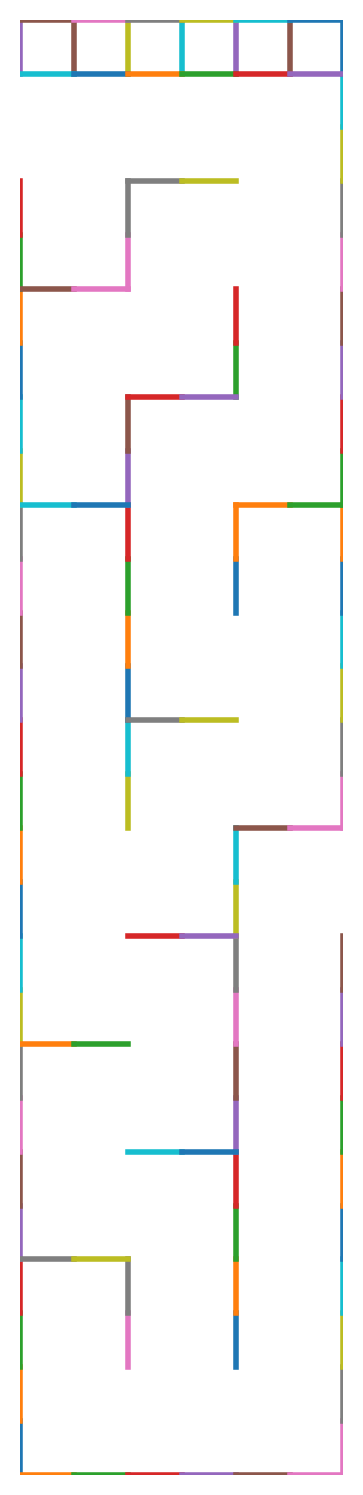

In [1]:
"""
6 tiles x 27 tiles maze generator (tile = 42cm x 42cm)

Design goal:
- Corridors are always >= 2 tiles wide so a 2x2-tile-clearance robot (Gita-like)
  can move without clipping corners.
- Entry + goal are 2-tiles-tall openings placed on the LONG SIDES (left/right)
  to increase complexity (not at the short ends).

How it works:
- Build a maze on a COARSE grid of 2x2-tile "macro-cells".
  Maze interior uses 6x26 tiles = (3 macro-cells wide) x (13 macro-cells tall).
- The remaining 1 tile (making height 27) is kept as a solid top boundary row,
  so overall footprint is exactly 6x27 tiles.
- Entry/goal are cut as 2-tile-high openings on left/right boundaries aligned
  to macro-cells.
- Exports: PNG + SVG + a text list of wall segments in tile coordinates.

Outputs are created in the current working directory by default.
"""

from __future__ import annotations
import random
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import matplotlib.pyplot as plt


# ---------------------------
# Parameters you can change
# ---------------------------
SEED = 1                       # change for a different maze
TILES_W, TILES_H = 6, 27       # fixed by spec
TILE_CM = 42                   # 1 tile = 42cm
MACRO = 2                      # each macro-cell is 2x2 tiles

# interior macro grid (must fit into tiles)
MACRO_W = TILES_W // MACRO            # 3
MACRO_H = (TILES_H - 1) // MACRO      # 13 (uses 26 tiles; 1 tile top row remains solid)


# ---------------------------
# Maze generation on macro grid
# ---------------------------
DIRS = {
    "N": (0, 1),
    "S": (0, -1),
    "E": (1, 0),
    "W": (-1, 0),
}
OPP = {"N": "S", "S": "N", "E": "W", "W": "E"}


@dataclass(frozen=True)
class MacroCell:
    x: int
    y: int


def in_bounds(x: int, y: int) -> bool:
    return 0 <= x < MACRO_W and 0 <= y < MACRO_H


def carve_perfect_maze(seed: int) -> Dict[MacroCell, set]:
    """
    Returns adjacency (passages) of a perfect maze (a spanning tree) on macro grid.
    """
    rng = random.Random(seed)
    start = MacroCell(rng.randrange(MACRO_W), rng.randrange(MACRO_H))
    stack = [start]
    visited = {start}
    adj: Dict[MacroCell, set] = {MacroCell(x, y): set() for x in range(MACRO_W) for y in range(MACRO_H)}

    while stack:
        c = stack[-1]
        neighbors = []
        for d, (dx, dy) in DIRS.items():
            nx, ny = c.x + dx, c.y + dy
            if in_bounds(nx, ny):
                n = MacroCell(nx, ny)
                if n not in visited:
                    neighbors.append((d, n))
        if not neighbors:
            stack.pop()
            continue
        d, n = rng.choice(neighbors)
        # carve passage both ways
        adj[c].add(n)
        adj[n].add(c)
        visited.add(n)
        stack.append(n)

    return adj


def bfs_farthest(adj: Dict[MacroCell, set], start: MacroCell) -> Tuple[MacroCell, Dict[MacroCell, int]]:
    q = deque([start])
    dist = {start: 0}
    far = start
    while q:
        u = q.popleft()
        if dist[u] > dist[far]:
            far = u
        for v in adj[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                q.append(v)
    return far, dist


def pick_entry_goal_on_long_sides(adj: Dict[MacroCell, set], seed: int) -> Tuple[MacroCell, MacroCell]:
    """
    Place entry and goal on long sides (left/right boundary macro-cells),
    maximizing path length across the macro maze.
    """
    rng = random.Random(seed + 999)

    left_side = [MacroCell(0, y) for y in range(MACRO_H)]
    right_side = [MacroCell(MACRO_W - 1, y) for y in range(MACRO_H)]

    # pick a random left cell, find farthest; then restrict to right side for goal.
    entry = rng.choice(left_side)
    _, dist_from_entry = bfs_farthest(adj, entry)

    # choose goal on right side with max distance
    goal = max(right_side, key=lambda c: dist_from_entry.get(c, -1))

    # (optional) If entry ended up too close to goal, try a few alternatives
    best = (entry, goal, dist_from_entry.get(goal, -1))
    for _ in range(20):
        e_try = rng.choice(left_side)
        _, d_try = bfs_farthest(adj, e_try)
        g_try = max(right_side, key=lambda c: d_try.get(c, -1))
        score = d_try.get(g_try, -1)
        if score > best[2]:
            best = (e_try, g_try, score)
    return best[0], best[1]


# ---------------------------
# Convert macro maze -> tile wall segments
# We'll represent walls along grid lines:
#   vertical walls: V[x][y] indicates a wall segment on line x from y to y+1 (tile units)
#   horizontal walls: H[x][y] indicates a wall segment on line y from x to x+1 (tile units)
# where:
#   x in [0..TILES_W], y in [0..TILES_H]
# ---------------------------
def init_all_walls() -> Tuple[List[List[bool]], List[List[bool]]]:
    V = [[True for _ in range(TILES_H)] for _ in range(TILES_W + 1)]  # segments along y
    H = [[True for _ in range(TILES_W)] for _ in range(TILES_H + 1)]  # segments along x
    return V, H


def remove_vertical(V, x: int, y0: int, y1: int):
    """Remove vertical wall segments on line x for y in [y0, y1)"""
    for y in range(y0, y1):
        if 0 <= x <= TILES_W and 0 <= y < TILES_H:
            V[x][y] = False


def remove_horizontal(H, y: int, x0: int, x1: int):
    """Remove horizontal wall segments on line y for x in [x0, x1)"""
    for x in range(x0, x1):
        if 0 <= y <= TILES_H and 0 <= x < TILES_W:
            H[y][x] = False


def build_tile_walls_from_macro(adj: Dict[MacroCell, set], entry: MacroCell, goal: MacroCell):
    V, H = init_all_walls()

    # Outer boundary stays, except entry/goal holes we carve later.
    # Carve interior open space: for each macro cell, remove internal walls inside its 2x2 block
    # so the 2x2 area is one open room.
    for mx in range(MACRO_W):
        for my in range(MACRO_H):
            x0 = mx * MACRO
            y0 = my * MACRO

            # remove the internal cross inside the 2x2 area:
            # - the vertical line at x0+1 across y0..y0+2
            # - the horizontal line at y0+1 across x0..x0+2
            remove_vertical(V, x0 + 1, y0, y0 + 2)
            remove_horizontal(H, y0 + 1, x0, x0 + 2)

            # also open the macro-cell boundary to create the room (keep boundary walls for maze edges)
            # We do NOT remove the perimeter walls of each macro cell here; we handle passages next.

    # Carve passages between neighboring macro cells by removing the separating wall spanning 2 tiles
    for c, nbrs in adj.items():
        for n in nbrs:
            # only carve each edge once
            if (n.x < c.x) or (n.x == c.x and n.y < c.y):
                continue
            dx = n.x - c.x
            dy = n.y - c.y
            cx0, cy0 = c.x * MACRO, c.y * MACRO

            if dx == 1 and dy == 0:
                # passage East: remove vertical wall at x=cx0+2 for y=cy0..cy0+2
                remove_vertical(V, cx0 + 2, cy0, cy0 + 2)
            elif dx == -1 and dy == 0:
                remove_vertical(V, cx0, cy0, cy0 + 2)
            elif dx == 0 and dy == 1:
                # passage North: remove horizontal wall at y=cy0+2 for x=cx0..cx0+2
                remove_horizontal(H, cy0 + 2, cx0, cx0 + 2)
            elif dx == 0 and dy == -1:
                remove_horizontal(H, cy0, cx0, cx0 + 2)

    # Keep the very top row (y in [26,27)) closed as part of boundary thickness.
    # That means leave walls intact there—already True by default.

    # Carve entry on LEFT boundary as a 2-tile-high opening aligned to entry macro-cell
    ey0 = entry.y * MACRO
    # left boundary is vertical line x=0
    remove_vertical(V, 0, ey0, ey0 + 2)

    # Carve goal on RIGHT boundary as a 2-tile-high opening aligned to goal macro-cell
    gy0 = goal.y * MACRO
    remove_vertical(V, TILES_W, gy0, gy0 + 2)

    # Ensure bottom and top are closed (no short-end openings) for added complexity
    # (already closed by default, but we can explicitly re-close if needed)
    # Nothing to do unless you later edit the code.

    return V, H


# ---------------------------
# Export / visualization
# ---------------------------
def walls_to_unit_segments(V, H):
    segs = []

    # vertical unit segments
    for x in range(TILES_W + 1):
        for y in range(TILES_H):
            if V[x][y]:
                segs.append(((x, y), (x, y + 1)))

    # horizontal unit segments
    for y in range(TILES_H + 1):
        for x in range(TILES_W):
            if H[y][x]:
                segs.append(((x, y), (x + 1, y)))

    return segs


def draw_maze(V, H, out_png="maze_6x27.png", out_svg="maze_6x27.svg"):
    fig = plt.figure(figsize=(6, 27 * 0.35), dpi=200)  # tall aspect
    ax = plt.gca()
    ax.set_aspect("equal")
    ax.set_xlim(0, TILES_W)
    ax.set_ylim(0, TILES_H)
    ax.axis("off")

    # draw walls
    segs = walls_to_unit_segments(V, H)
    for (x0, y0), (x1, y1) in segs:
        ax.plot([x0, x1], [y0, y1], linewidth=2)

    # # light tile grid (optional) – comment out if you don't want it
    # for x in range(TILES_W + 1):
    #     ax.plot([x, x], [0, TILES_H], linewidth=0.2, alpha=0.25)
    # for y in range(TILES_H + 1):
    #     ax.plot([0, TILES_W], [y, y], linewidth=0.2, alpha=0.25)

    # plt.tight_layout(pad=0)
    # fig.savefig(out_png, bbox_inches="tight", pad_inches=0)
    # fig.savefig(out_svg, bbox_inches="tight", pad_inches=0)
    # plt.close(fig)


def export_wall_list(segs, out_txt="maze_walls_tile_coords.txt"):
    with open(out_txt, "w") as f:
        f.write("# Wall segments in tile-grid coordinates\n")
        f.write("# Each line: (x0,y0) -> (x1,y1)\n\n")
        for (x0, y0), (x1, y1) in segs:
            f.write(f"({x0},{y0}) -> ({x1},{y1})\n")


def main():
    adj = carve_perfect_maze(SEED)
    entry, goal = pick_entry_goal_on_long_sides(adj, SEED)

    V, H = build_tile_walls_from_macro(adj, entry, goal)
    draw_maze(V, H)

    # segs = walls_to_segments(V, H)
    # export_wall_list(segs)
    segs = walls_to_unit_segments(V, H)
    print("SEGMENT COUNT =", len(segs))
    export_wall_list(segs)


    print("Generated:")
    print(" - maze_6x27.png")
    print(" - maze_6x27.svg")
    print(" - maze_walls_tile_coords.txt")
    print()
    print(f"Tile footprint: {TILES_W} x {TILES_H} tiles  = {TILES_W*TILE_CM}cm x {TILES_H*TILE_CM}cm")
    print(f"Entry (left side) aligned to macro-cell: {entry}  => opening y=[{entry.y*2},{entry.y*2+2}) tiles")
    print(f"Goal  (right side) aligned to macro-cell: {goal}  => opening y=[{goal.y*2},{goal.y*2+2}) tiles")


if __name__ == "__main__":
    main()
